# Augmentation Strategy Analysis for SIGReg Pretraining

This notebook visualises and evaluates the two-view augmentation strategy used in `PeakSetSIGReg`:

1. **Peak dropping** – randomly drop valid peaks with probability `sigreg_drop_prob`
2. **M/z jitter** – Gaussian noise with std `sigreg_mz_jitter_std`
3. **Intensity jitter** – Gaussian noise with std `sigreg_intensity_jitter_std`, followed by re-normalisation

We load real spectra from the dataset, apply the augmentations with the config values, and inspect:
- Original vs augmented spectra (stem plots)
- Drop rate distributions across a batch
- M/z and intensity perturbation distributions
- Cross-view agreement (Jaccard / cosine similarity)
- Sensitivity sweep over augmentation hyperparameters

In [2]:
import sys
sys.path.insert(0, "..")

import importlib.util
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=1.1)

DEVICE = "cuda"
torch.manual_seed(42)
np.random.seed(42)

## 1. Load config and data

In [3]:
from ml_collections import config_dict

def load_config(path: str) -> config_dict.ConfigDict:
    spec = importlib.util.spec_from_file_location("cfg", path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod.get_config()

config = load_config("../configs/gems_a_50_mask.py")

print(f"drop_prob = {config.sigreg_drop_prob}")
print(f"mz_jitter_std = {config.sigreg_mz_jitter_std}")
print(f"intensity_jitter_std = {config.sigreg_intensity_jitter_std}")
print(f"batch_size = {config.batch_size}")
print(f"num_peaks = {config.num_peaks}")

drop_prob = 0.25
mz_jitter_std = 0.01
intensity_jitter_std = 0.1
batch_size = 512
num_peaks = 60


In [4]:
import tensorflow as tf
tf.config.set_visible_devices([], "GPU")

from input_pipeline import (
    _build_dataset, _NUM_PEAKS_OUTPUT, _PEAK_MZ_MAX,
    numpy_batch_to_torch,
)

# Load directly from existing TFRecords — avoids the slow _ensure_processed check
TFRECORD_DIR = Path("../data/gems_peaklist_tfrecord")
train_files = sorted(str(p) for p in (TFRECORD_DIR / "train").glob("*.tfrecord"))
print(f"Found {len(train_files)} train shards")

ds = _build_dataset(
    train_files,
    batch_size=config.batch_size,
    shuffle_buffer=1000,  # small buffer for quick loading
    seed=42,
    drop_remainder=True,
    tfrecord_buffer_size=250_000,
    max_precursor_mz=config.max_precursor_mz,
    include_fingerprint=False,
    intensity_scaling=config.intensity_scaling,
    mz_representation=config.mz_representation,
    peak_ordering=config.peak_ordering,
    num_parallel_reads=1,
)

batch_np = next(ds.as_numpy_iterator())
batch = numpy_batch_to_torch(batch_np)

for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(f"{k}: {v.shape} {v.dtype}")

2026-02-10 08:06:32.727037: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-10 08:06:32.759305: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-10 08:06:33.738258: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/tqdm

Found 4 train shards
rt: torch.Size([512]) torch.float32
precursor_mz: torch.Size([512]) torch.float32
peak_valid_mask: torch.Size([512, 60]) torch.bool
peak_mz: torch.Size([512, 60]) torch.float32
peak_intensity: torch.Size([512, 60]) torch.float32


2026-02-10 08:06:36.171635: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 250000


## 2. Standalone augmentation function

We extract the augmentation logic from `PeakSetSIGReg._augment_view` so we can call it independently.

In [5]:
def augment_view(
    peak_mz: torch.Tensor,
    peak_intensity: torch.Tensor,
    peak_valid_mask: torch.Tensor,
    *,
    drop_prob: float,
    mz_jitter_std: float,
    intensity_jitter_std: float,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Standalone version of PeakSetSIGReg._augment_view."""
    drop = (torch.rand_like(peak_mz) < drop_prob) & peak_valid_mask
    view_valid = peak_valid_mask & (~drop)

    mz = peak_mz + torch.randn_like(peak_mz) * mz_jitter_std
    mz = torch.clamp(mz, min=0.0, max=1.0)

    intensity = peak_intensity + torch.randn_like(peak_intensity) * intensity_jitter_std
    intensity = torch.clamp(intensity, min=0.0, max=1.0)

    mz = torch.where(view_valid, mz, torch.zeros_like(mz))
    intensity = torch.where(view_valid, intensity, torch.zeros_like(intensity))

    max_intensity = intensity.max(dim=1, keepdim=True).values.clamp(min=1e-6)
    intensity = intensity / max_intensity
    intensity = torch.where(view_valid, intensity, torch.zeros_like(intensity))

    return mz, intensity, view_valid

# Generate two views from config values
peak_mz = batch["peak_mz"]
peak_int = batch["peak_intensity"]
peak_mask = batch["peak_valid_mask"]

DROP_PROB = config.sigreg_drop_prob
MZ_STD = config.sigreg_mz_jitter_std
INT_STD = config.sigreg_intensity_jitter_std

torch.manual_seed(0)
v1_mz, v1_int, v1_mask = augment_view(peak_mz, peak_int, peak_mask,
                                       drop_prob=DROP_PROB, mz_jitter_std=MZ_STD,
                                       intensity_jitter_std=INT_STD)
v2_mz, v2_int, v2_mask = augment_view(peak_mz, peak_int, peak_mask,
                                       drop_prob=DROP_PROB, mz_jitter_std=MZ_STD,
                                       intensity_jitter_std=INT_STD)

print(f"Batch shape: {peak_mz.shape}")
print(f"Original valid peaks (sample 0): {peak_mask[0].sum().item()}")
print(f"View 1 valid peaks (sample 0): {v1_mask[0].sum().item()}")
print(f"View 2 valid peaks (sample 0): {v2_mask[0].sum().item()}")

Batch shape: torch.Size([512, 60])
Original valid peaks (sample 0): 60
View 1 valid peaks (sample 0): 41
View 2 valid peaks (sample 0): 44


## 3. Stem plots: Original vs. Two Augmented Views

Visualise individual spectra as stem (lollipop) plots. Each column is one sample; rows show original, view 1, and view 2.

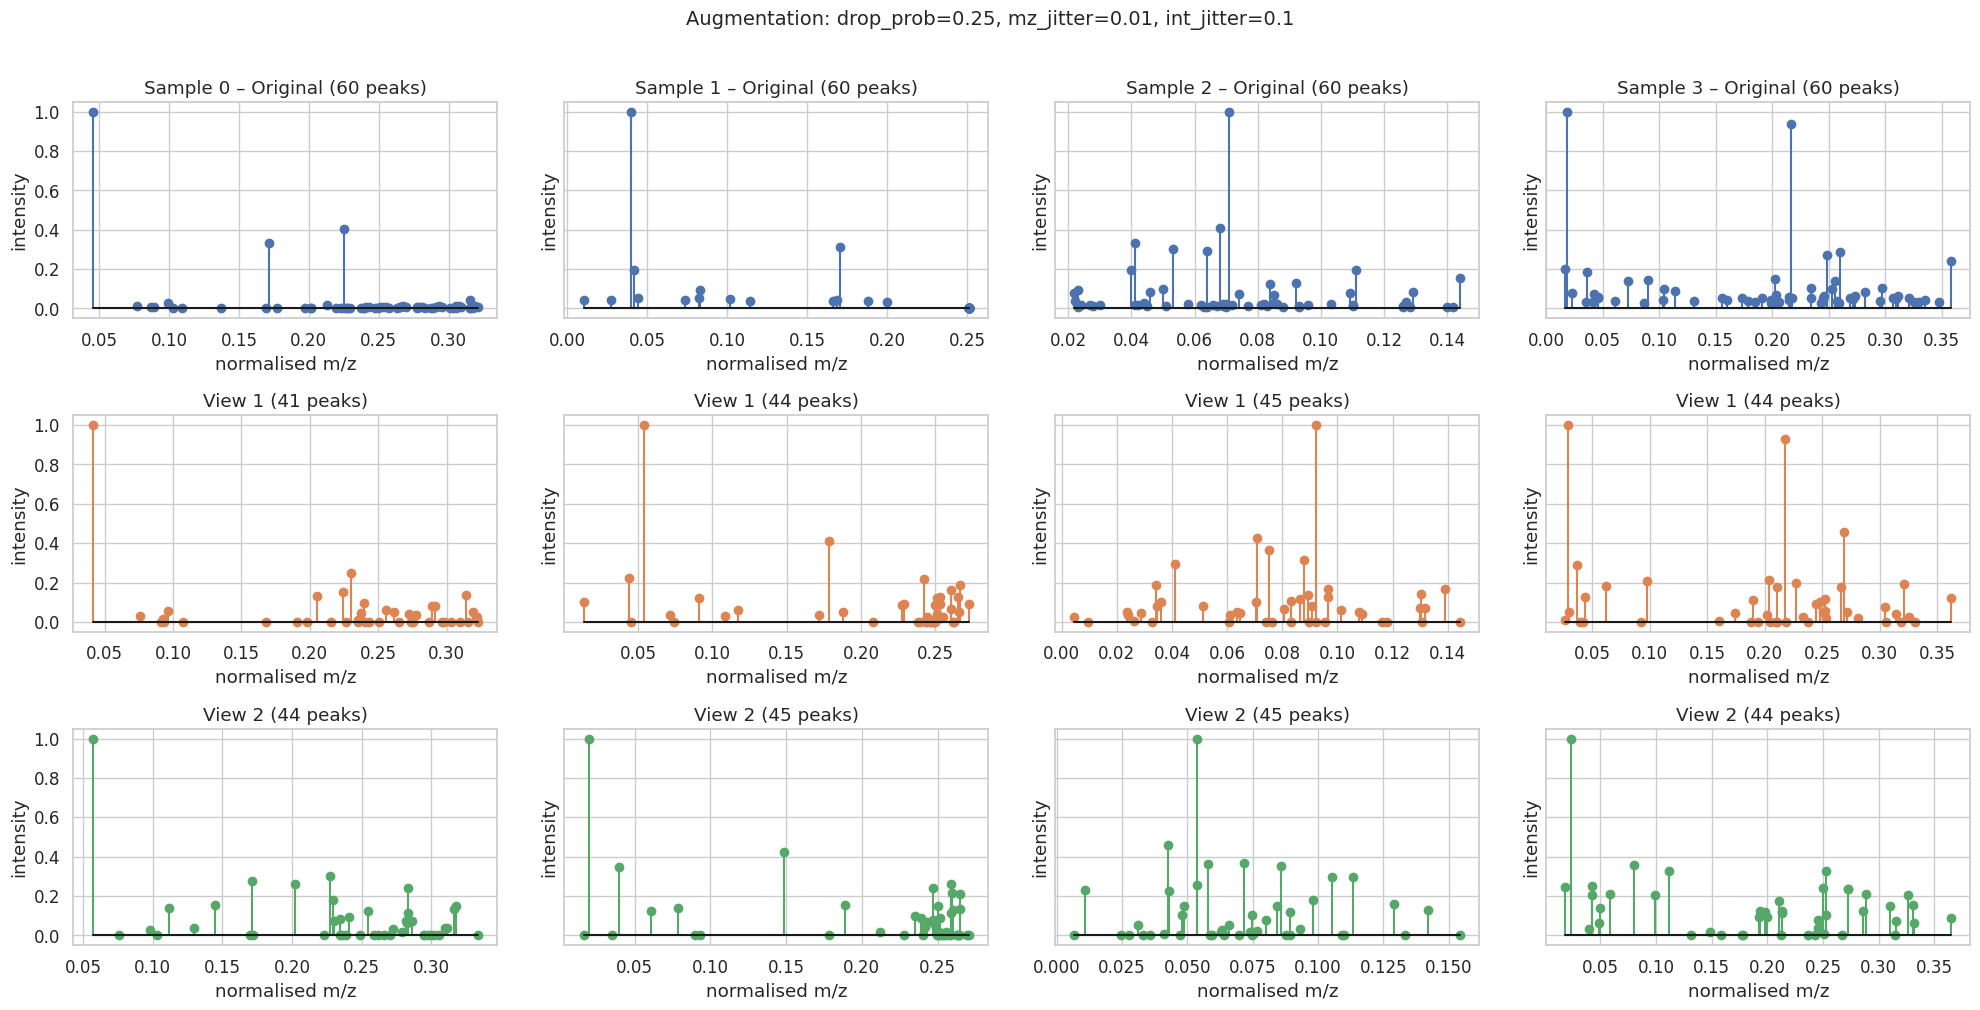

In [6]:
NUM_SAMPLES = 4

fig, axes = plt.subplots(3, NUM_SAMPLES, figsize=(5 * NUM_SAMPLES, 10), sharey="row")

for col in range(NUM_SAMPLES):
    idx = col
    # Original
    mask_orig = peak_mask[idx].numpy()
    mz_orig = peak_mz[idx].numpy()[mask_orig]
    int_orig = peak_int[idx].numpy()[mask_orig]
    axes[0, col].stem(mz_orig, int_orig, linefmt="C0-", markerfmt="C0o", basefmt="k-")
    axes[0, col].set_title(f"Sample {idx} – Original ({mask_orig.sum()} peaks)")

    # View 1
    m1 = v1_mask[idx].numpy()
    axes[1, col].stem(v1_mz[idx].numpy()[m1], v1_int[idx].numpy()[m1],
                      linefmt="C1-", markerfmt="C1o", basefmt="k-")
    axes[1, col].set_title(f"View 1 ({m1.sum()} peaks)")

    # View 2
    m2 = v2_mask[idx].numpy()
    axes[2, col].stem(v2_mz[idx].numpy()[m2], v2_int[idx].numpy()[m2],
                      linefmt="C2-", markerfmt="C2o", basefmt="k-")
    axes[2, col].set_title(f"View 2 ({m2.sum()} peaks)")

for ax in axes.flat:
    ax.set_xlabel("normalised m/z")
    ax.set_ylabel("intensity")

fig.suptitle(f"Augmentation: drop_prob={DROP_PROB}, mz_jitter={MZ_STD}, int_jitter={INT_STD}",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## 4. Overlay plot: Original vs. Augmented (single sample)

Side-by-side comparison showing which peaks were dropped and how positions/intensities shifted.

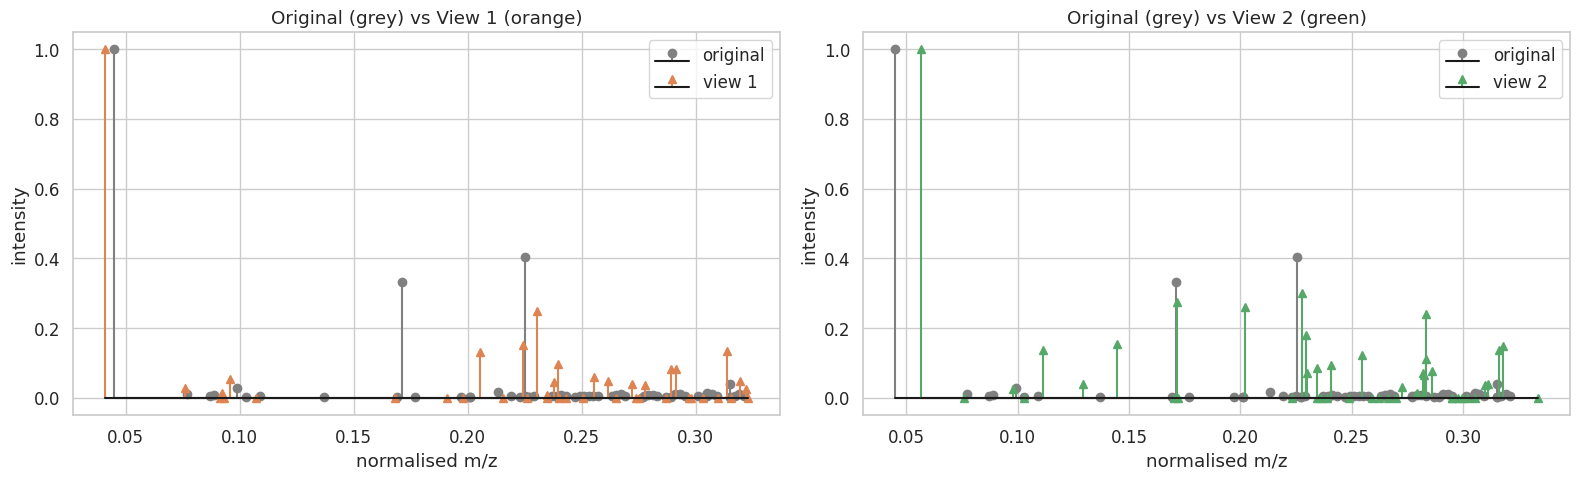

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sample_idx = 0
m_orig = peak_mask[sample_idx].numpy()

# View 1 overlay
ax = axes[0]
ax.stem(peak_mz[sample_idx].numpy()[m_orig], peak_int[sample_idx].numpy()[m_orig],
        linefmt="grey", markerfmt="o", basefmt="k-", label="original")
m1 = v1_mask[sample_idx].numpy()
ax.stem(v1_mz[sample_idx].numpy()[m1], v1_int[sample_idx].numpy()[m1],
        linefmt="C1-", markerfmt="C1^", basefmt="k-", label="view 1")
ax.set_title("Original (grey) vs View 1 (orange)")
ax.legend()
ax.set_xlabel("normalised m/z")
ax.set_ylabel("intensity")

# View 2 overlay
ax = axes[1]
ax.stem(peak_mz[sample_idx].numpy()[m_orig], peak_int[sample_idx].numpy()[m_orig],
        linefmt="grey", markerfmt="o", basefmt="k-", label="original")
m2 = v2_mask[sample_idx].numpy()
ax.stem(v2_mz[sample_idx].numpy()[m2], v2_int[sample_idx].numpy()[m2],
        linefmt="C2-", markerfmt="C2^", basefmt="k-", label="view 2")
ax.set_title("Original (grey) vs View 2 (green)")
ax.legend()
ax.set_xlabel("normalised m/z")
ax.set_ylabel("intensity")

fig.tight_layout()
plt.show()

## 5. Drop rate analysis across the batch

Distribution of the fraction of valid peaks that survive augmentation.

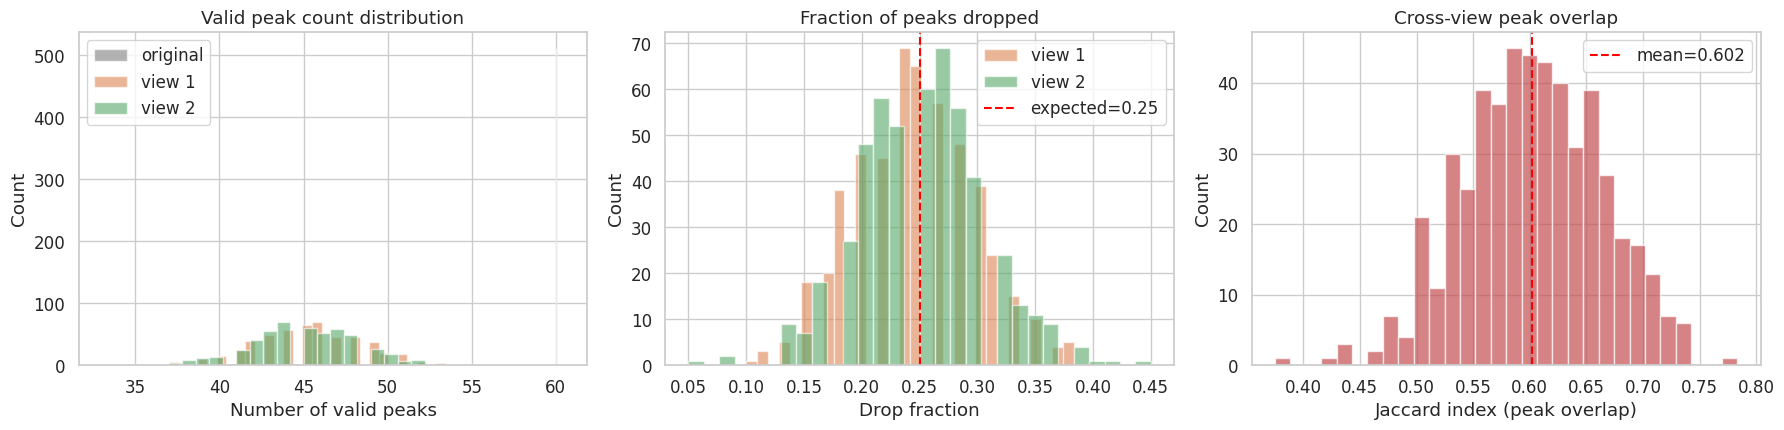

Mean drop fraction – view1: 0.2449, view2: 0.2503
Mean Jaccard overlap: 0.6023


In [8]:
n_valid_orig = peak_mask.float().sum(dim=1)
n_valid_v1 = v1_mask.float().sum(dim=1)
n_valid_v2 = v2_mask.float().sum(dim=1)

survival_v1 = (n_valid_v1 / n_valid_orig.clamp(min=1)).numpy()
survival_v2 = (n_valid_v2 / n_valid_orig.clamp(min=1)).numpy()
drop_frac_v1 = 1.0 - survival_v1
drop_frac_v2 = 1.0 - survival_v2

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Histogram: peaks surviving
axes[0].hist(n_valid_orig.numpy(), bins=30, alpha=0.6, label="original", color="grey")
axes[0].hist(n_valid_v1.numpy(), bins=30, alpha=0.6, label="view 1", color="C1")
axes[0].hist(n_valid_v2.numpy(), bins=30, alpha=0.6, label="view 2", color="C2")
axes[0].set_xlabel("Number of valid peaks")
axes[0].set_ylabel("Count")
axes[0].set_title("Valid peak count distribution")
axes[0].legend()

# Drop fraction histogram
axes[1].hist(drop_frac_v1, bins=30, alpha=0.6, label="view 1", color="C1")
axes[1].hist(drop_frac_v2, bins=30, alpha=0.6, label="view 2", color="C2")
axes[1].axvline(DROP_PROB, color="red", ls="--", label=f"expected={DROP_PROB}")
axes[1].set_xlabel("Drop fraction")
axes[1].set_ylabel("Count")
axes[1].set_title("Fraction of peaks dropped")
axes[1].legend()

# Cross-view overlap (Jaccard on peak indices)
both_valid = (v1_mask & v2_mask).float().sum(dim=1)
either_valid = (v1_mask | v2_mask).float().sum(dim=1)
jaccard = (both_valid / either_valid.clamp(min=1)).numpy()

axes[2].hist(jaccard, bins=30, color="C3", alpha=0.7)
axes[2].axvline(jaccard.mean(), color="red", ls="--", label=f"mean={jaccard.mean():.3f}")
axes[2].set_xlabel("Jaccard index (peak overlap)")
axes[2].set_ylabel("Count")
axes[2].set_title("Cross-view peak overlap")
axes[2].legend()

fig.tight_layout()
plt.show()

print(f"Mean drop fraction – view1: {drop_frac_v1.mean():.4f}, view2: {drop_frac_v2.mean():.4f}")
print(f"Mean Jaccard overlap: {jaccard.mean():.4f}")

## 6. Jitter magnitude analysis

Inspect the actual perturbation applied to m/z and intensity values for peaks that survive in both views.

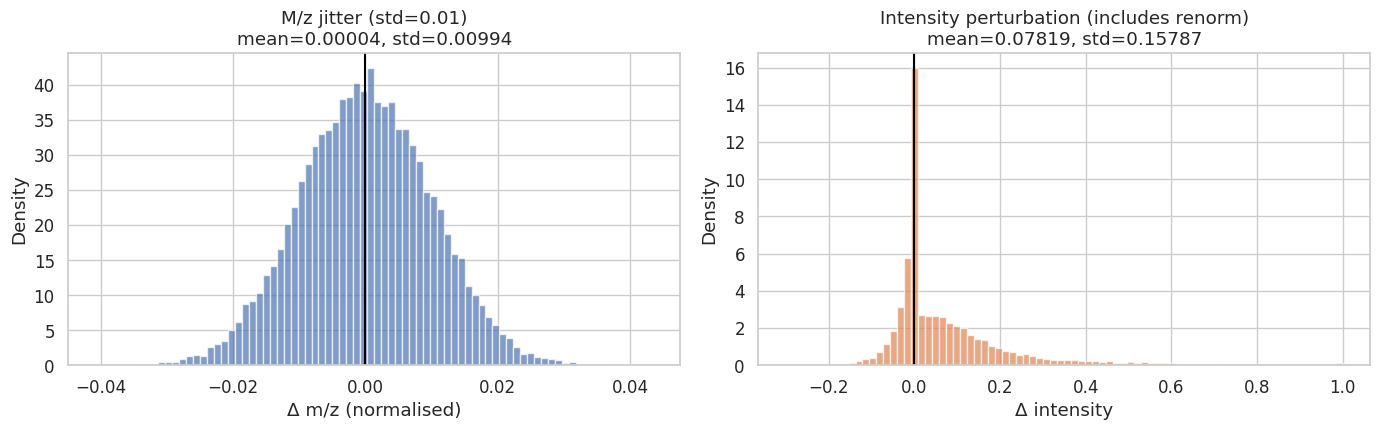

In [9]:
# Compute perturbations on peaks valid in both original and augmented view
shared_mask = peak_mask & v1_mask  # peaks surviving in view 1

mz_delta = (v1_mz - peak_mz)[shared_mask].numpy()
int_delta_raw = (v1_int - peak_int)[shared_mask].numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# M/z jitter
axes[0].hist(mz_delta, bins=80, color="C0", alpha=0.7, density=True)
axes[0].axvline(0, color="black", ls="-")
axes[0].set_xlabel("Δ m/z (normalised)")
axes[0].set_ylabel("Density")
axes[0].set_title(f"M/z jitter (std={MZ_STD})\nmean={mz_delta.mean():.5f}, std={mz_delta.std():.5f}")

# Intensity jitter (raw, before re-normalisation)
axes[1].hist(int_delta_raw, bins=80, color="C1", alpha=0.7, density=True)
axes[1].axvline(0, color="black", ls="-")
axes[1].set_xlabel("Δ intensity")
axes[1].set_ylabel("Density")
axes[1].set_title(f"Intensity perturbation (includes renorm)\nmean={int_delta_raw.mean():.5f}, std={int_delta_raw.std():.5f}")

fig.tight_layout()
plt.show()

## 7. Per-peak jitter scatter: original vs. augmented

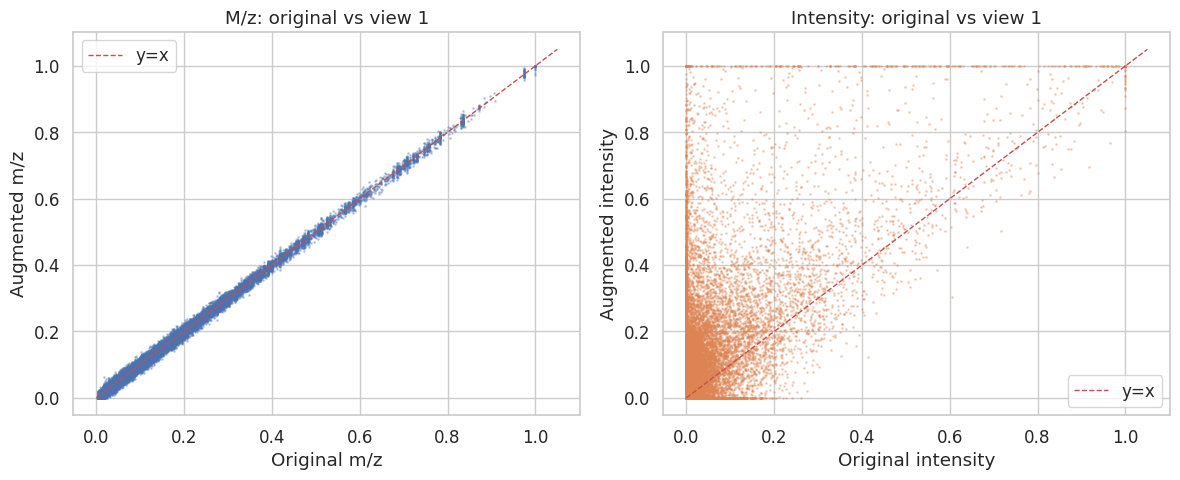

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# M/z: original vs view 1
orig_mz_vals = peak_mz[shared_mask].numpy()
aug_mz_vals = v1_mz[shared_mask].numpy()
axes[0].scatter(orig_mz_vals, aug_mz_vals, s=1, alpha=0.3)
lims = [0, max(orig_mz_vals.max(), aug_mz_vals.max()) * 1.05]
axes[0].plot(lims, lims, "r--", lw=1, label="y=x")
axes[0].set_xlabel("Original m/z")
axes[0].set_ylabel("Augmented m/z")
axes[0].set_title("M/z: original vs view 1")
axes[0].legend()

# Intensity: original vs view 1
orig_int_vals = peak_int[shared_mask].numpy()
aug_int_vals = v1_int[shared_mask].numpy()
axes[1].scatter(orig_int_vals, aug_int_vals, s=1, alpha=0.3, color="C1")
lims = [0, max(orig_int_vals.max(), aug_int_vals.max()) * 1.05]
axes[1].plot(lims, lims, "r--", lw=1, label="y=x")
axes[1].set_xlabel("Original intensity")
axes[1].set_ylabel("Augmented intensity")
axes[1].set_title("Intensity: original vs view 1")
axes[1].legend()

fig.tight_layout()
plt.show()

## 8. Cross-view feature similarity

Compute cosine similarity between the two augmented views in raw peak feature space (concatenated m/z + intensity vectors). This gives a baseline for how similar the views are before any encoder processing.

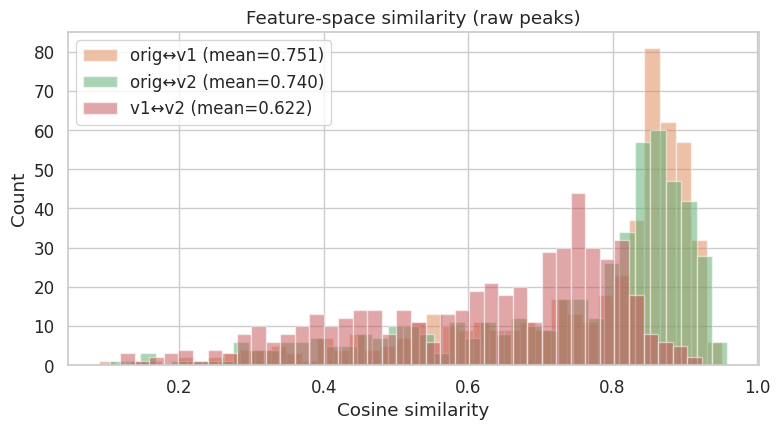

In [11]:
import torch.nn.functional as F

# Flatten each spectrum: concat mz and intensity -> [B, 2*N]
def flat_features(mz, intensity, mask):
    mz_masked = torch.where(mask, mz, torch.zeros_like(mz))
    int_masked = torch.where(mask, intensity, torch.zeros_like(intensity))
    return torch.cat([mz_masked, int_masked], dim=1)

feat_orig = flat_features(peak_mz, peak_int, peak_mask)
feat_v1 = flat_features(v1_mz, v1_int, v1_mask)
feat_v2 = flat_features(v2_mz, v2_int, v2_mask)

cos_v1_v2 = F.cosine_similarity(feat_v1, feat_v2, dim=1).numpy()
cos_orig_v1 = F.cosine_similarity(feat_orig, feat_v1, dim=1).numpy()
cos_orig_v2 = F.cosine_similarity(feat_orig, feat_v2, dim=1).numpy()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(cos_orig_v1, bins=40, alpha=0.5, label=f"orig↔v1 (mean={cos_orig_v1.mean():.3f})", color="C1")
ax.hist(cos_orig_v2, bins=40, alpha=0.5, label=f"orig↔v2 (mean={cos_orig_v2.mean():.3f})", color="C2")
ax.hist(cos_v1_v2, bins=40, alpha=0.5, label=f"v1↔v2 (mean={cos_v1_v2.mean():.3f})", color="C3")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Count")
ax.set_title("Feature-space similarity (raw peaks)")
ax.legend()
fig.tight_layout()
plt.show()

## 9. Augmentation strength sweep

Sweep over a range of `drop_prob`, `mz_jitter_std`, and `intensity_jitter_std` values. For each setting, measure:
- Mean Jaccard overlap between views
- Mean cosine similarity between views in raw feature space

This helps understand the sensitivity of the augmentation and whether the current config is in a reasonable regime.

In [12]:
def evaluate_augmentation(
    peak_mz, peak_int, peak_mask, *, drop_prob, mz_std, int_std, n_trials=5
):
    """Run augmentation n_trials times and return mean metrics."""
    jaccards, cosines = [], []
    for t in range(n_trials):
        v1_mz, v1_int, v1_mask = augment_view(
            peak_mz, peak_int, peak_mask,
            drop_prob=drop_prob, mz_jitter_std=mz_std, intensity_jitter_std=int_std,
        )
        v2_mz, v2_int, v2_mask = augment_view(
            peak_mz, peak_int, peak_mask,
            drop_prob=drop_prob, mz_jitter_std=mz_std, intensity_jitter_std=int_std,
        )
        both = (v1_mask & v2_mask).float().sum(dim=1)
        either = (v1_mask | v2_mask).float().sum(dim=1)
        jac = (both / either.clamp(min=1)).mean().item()
        jaccards.append(jac)

        f1 = flat_features(v1_mz, v1_int, v1_mask)
        f2 = flat_features(v2_mz, v2_int, v2_mask)
        cos = F.cosine_similarity(f1, f2, dim=1).mean().item()
        cosines.append(cos)

    return np.mean(jaccards), np.mean(cosines)

# Use a subset for speed
sub = 128
pmz, pint, pmask = peak_mz[:sub], peak_int[:sub], peak_mask[:sub]

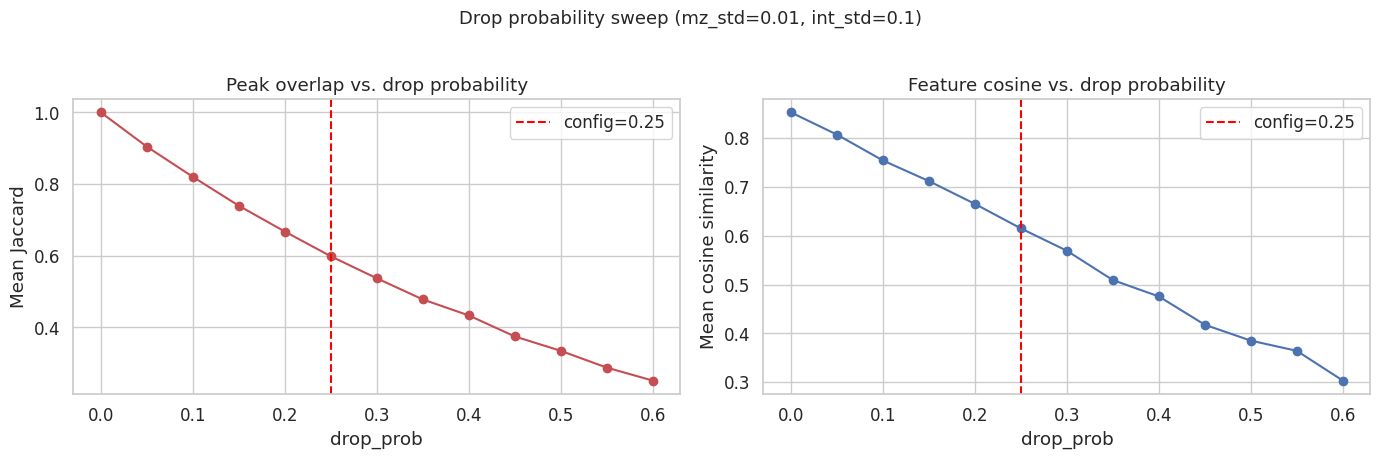

In [13]:
drop_probs = np.arange(0, 0.65, 0.05)
drop_results = []
for dp in drop_probs:
    jac, cos = evaluate_augmentation(pmz, pint, pmask, drop_prob=dp, mz_std=MZ_STD, int_std=INT_STD)
    drop_results.append((dp, jac, cos))
drop_results = np.array(drop_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(drop_results[:, 0], drop_results[:, 1], "o-", color="C3")
axes[0].axvline(DROP_PROB, color="red", ls="--", label=f"config={DROP_PROB}")
axes[0].set_xlabel("drop_prob")
axes[0].set_ylabel("Mean Jaccard")
axes[0].set_title("Peak overlap vs. drop probability")
axes[0].legend()

axes[1].plot(drop_results[:, 0], drop_results[:, 2], "o-", color="C0")
axes[1].axvline(DROP_PROB, color="red", ls="--", label=f"config={DROP_PROB}")
axes[1].set_xlabel("drop_prob")
axes[1].set_ylabel("Mean cosine similarity")
axes[1].set_title("Feature cosine vs. drop probability")
axes[1].legend()

fig.suptitle(f"Drop probability sweep (mz_std={MZ_STD}, int_std={INT_STD})", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

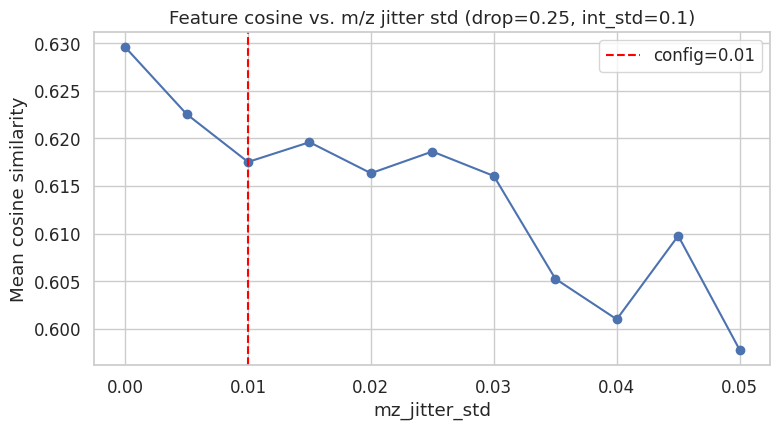

In [14]:
mz_stds = np.arange(0, 0.055, 0.005)
mz_results = []
for ms in mz_stds:
    jac, cos = evaluate_augmentation(pmz, pint, pmask, drop_prob=DROP_PROB, mz_std=ms, int_std=INT_STD)
    mz_results.append((ms, jac, cos))
mz_results = np.array(mz_results)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(mz_results[:, 0], mz_results[:, 2], "o-", color="C0")
ax.axvline(MZ_STD, color="red", ls="--", label=f"config={MZ_STD}")
ax.set_xlabel("mz_jitter_std")
ax.set_ylabel("Mean cosine similarity")
ax.set_title(f"Feature cosine vs. m/z jitter std (drop={DROP_PROB}, int_std={INT_STD})")
ax.legend()
fig.tight_layout()
plt.show()

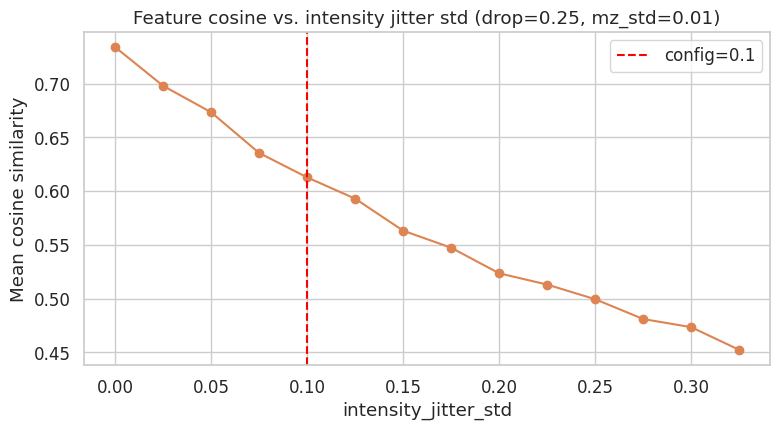

In [15]:
int_stds = np.arange(0, 0.35, 0.025)
int_results = []
for ist in int_stds:
    jac, cos = evaluate_augmentation(pmz, pint, pmask, drop_prob=DROP_PROB, mz_std=MZ_STD, int_std=ist)
    int_results.append((ist, jac, cos))
int_results = np.array(int_results)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(int_results[:, 0], int_results[:, 2], "o-", color="C1")
ax.axvline(INT_STD, color="red", ls="--", label=f"config={INT_STD}")
ax.set_xlabel("intensity_jitter_std")
ax.set_ylabel("Mean cosine similarity")
ax.set_title(f"Feature cosine vs. intensity jitter std (drop={DROP_PROB}, mz_std={MZ_STD})")
ax.legend()
fig.tight_layout()
plt.show()

## 10. 2D heatmap: drop_prob vs intensity_jitter_std

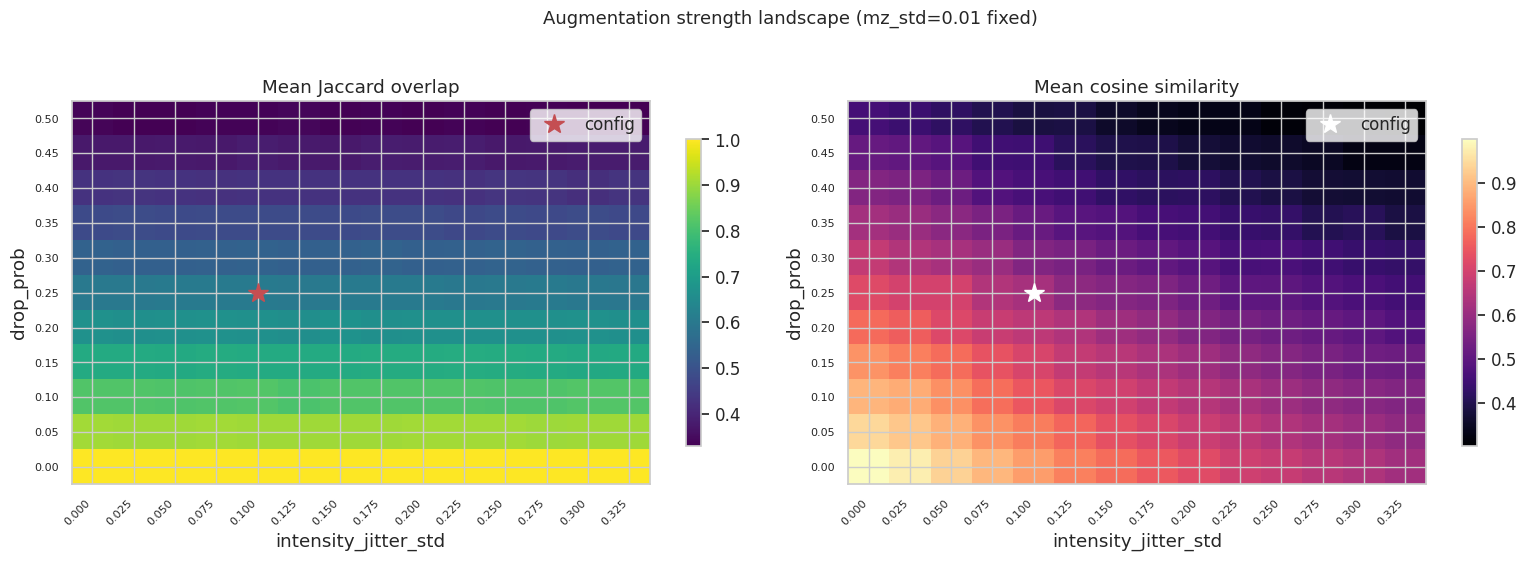

In [16]:
drop_vals = np.arange(0.0, 0.55, 0.05)
int_vals = np.arange(0.0, 0.35, 0.025)

jac_grid = np.zeros((len(drop_vals), len(int_vals)))
cos_grid = np.zeros((len(drop_vals), len(int_vals)))

for i, dp in enumerate(drop_vals):
    for j, ist in enumerate(int_vals):
        jac, cos = evaluate_augmentation(
            pmz, pint, pmask, drop_prob=dp, mz_std=MZ_STD, int_std=ist, n_trials=3
        )
        jac_grid[i, j] = jac
        cos_grid[i, j] = cos

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Jaccard heatmap
im0 = axes[0].imshow(jac_grid, aspect="auto", origin="lower", cmap="viridis")
axes[0].set_xticks(range(len(int_vals)))
axes[0].set_xticklabels([f"{v:.3f}" for v in int_vals], rotation=45, ha="right", fontsize=8)
axes[0].set_yticks(range(len(drop_vals)))
axes[0].set_yticklabels([f"{v:.2f}" for v in drop_vals], fontsize=8)
axes[0].set_xlabel("intensity_jitter_std")
axes[0].set_ylabel("drop_prob")
axes[0].set_title("Mean Jaccard overlap")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

# Mark config point
ci = np.argmin(np.abs(int_vals - INT_STD))
cd = np.argmin(np.abs(drop_vals - DROP_PROB))
axes[0].plot(ci, cd, "r*", markersize=15, label="config")
axes[0].legend()

# Cosine heatmap
im1 = axes[1].imshow(cos_grid, aspect="auto", origin="lower", cmap="magma")
axes[1].set_xticks(range(len(int_vals)))
axes[1].set_xticklabels([f"{v:.3f}" for v in int_vals], rotation=45, ha="right", fontsize=8)
axes[1].set_yticks(range(len(drop_vals)))
axes[1].set_yticklabels([f"{v:.2f}" for v in drop_vals], fontsize=8)
axes[1].set_xlabel("intensity_jitter_std")
axes[1].set_ylabel("drop_prob")
axes[1].set_title("Mean cosine similarity")
fig.colorbar(im1, ax=axes[1], shrink=0.8)
axes[1].plot(ci, cd, "w*", markersize=15, label="config")
axes[1].legend()

fig.suptitle(f"Augmentation strength landscape (mz_std={MZ_STD} fixed)", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 11. Intensity re-normalisation effect

After intensity jitter, the augmentation divides by the new max intensity per spectrum. This can amplify or compress the intensity distribution. Let's visualise this.

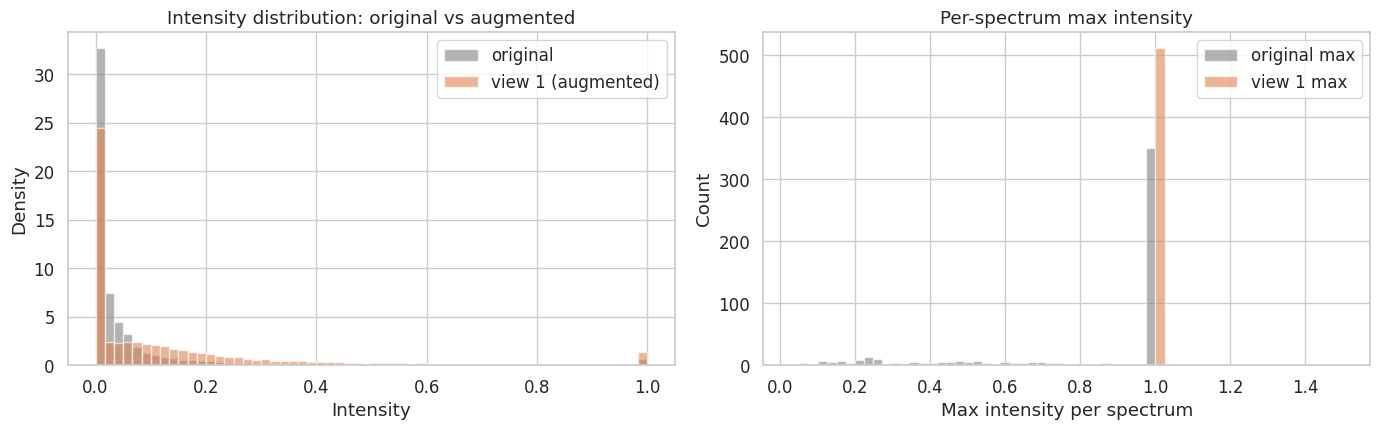

Augmented spectra with max intensity = 1.0: 512 / 512


In [17]:
# Compare intensity distributions before and after augmentation
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

orig_int_valid = peak_int[peak_mask].numpy()
v1_int_valid = v1_int[v1_mask].numpy()

axes[0].hist(orig_int_valid, bins=60, alpha=0.6, label="original", color="grey", density=True)
axes[0].hist(v1_int_valid, bins=60, alpha=0.6, label="view 1 (augmented)", color="C1", density=True)
axes[0].set_xlabel("Intensity")
axes[0].set_ylabel("Density")
axes[0].set_title("Intensity distribution: original vs augmented")
axes[0].legend()

# Max intensity per spectrum (should be ~1.0 after renorm)
max_orig = peak_int.max(dim=1).values.numpy()
max_v1 = v1_int.max(dim=1).values.numpy()

axes[1].hist(max_orig, bins=40, alpha=0.6, label="original max", color="grey")
axes[1].hist(max_v1, bins=40, alpha=0.6, label="view 1 max", color="C1")
axes[1].set_xlabel("Max intensity per spectrum")
axes[1].set_ylabel("Count")
axes[1].set_title("Per-spectrum max intensity")
axes[1].legend()

fig.tight_layout()
plt.show()

print(f"Augmented spectra with max intensity = 1.0: {(np.abs(max_v1 - 1.0) < 1e-5).sum()} / {len(max_v1)}")

## 12. Rank-order preservation

A key question for augmentation: does the rank ordering of peaks by intensity survive augmentation? If the model uses intensity ordering as a signal, we want moderate disruption but not total scrambling.

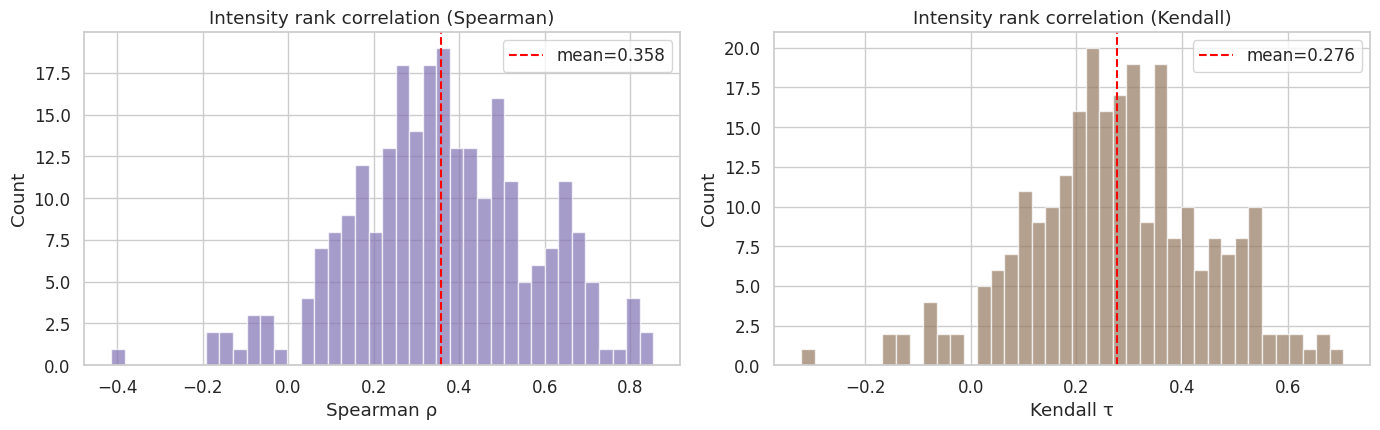

Spearman ρ: mean=0.3576, std=0.2141
Kendall  τ: mean=0.2759, std=0.1683


In [18]:
from scipy.stats import spearmanr, kendalltau

spearman_corrs = []
kendall_corrs = []

for i in range(min(256, peak_mz.shape[0])):
    # Peaks valid in both original and view 1
    shared = peak_mask[i] & v1_mask[i]
    if shared.sum() < 3:
        continue
    orig_vals = peak_int[i][shared].numpy()
    aug_vals = v1_int[i][shared].numpy()
    if orig_vals.std() < 1e-8 or aug_vals.std() < 1e-8:
        continue
    sp, _ = spearmanr(orig_vals, aug_vals)
    kt, _ = kendalltau(orig_vals, aug_vals)
    spearman_corrs.append(sp)
    kendall_corrs.append(kt)

spearman_corrs = np.array(spearman_corrs)
kendall_corrs = np.array(kendall_corrs)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(spearman_corrs, bins=40, color="C4", alpha=0.7)
axes[0].axvline(spearman_corrs.mean(), color="red", ls="--",
                label=f"mean={spearman_corrs.mean():.3f}")
axes[0].set_xlabel("Spearman ρ")
axes[0].set_ylabel("Count")
axes[0].set_title("Intensity rank correlation (Spearman)")
axes[0].legend()

axes[1].hist(kendall_corrs, bins=40, color="C5", alpha=0.7)
axes[1].axvline(kendall_corrs.mean(), color="red", ls="--",
                label=f"mean={kendall_corrs.mean():.3f}")
axes[1].set_xlabel("Kendall τ")
axes[1].set_ylabel("Count")
axes[1].set_title("Intensity rank correlation (Kendall)")
axes[1].legend()

fig.tight_layout()
plt.show()

print(f"Spearman ρ: mean={spearman_corrs.mean():.4f}, std={spearman_corrs.std():.4f}")
print(f"Kendall  τ: mean={kendall_corrs.mean():.4f}, std={kendall_corrs.std():.4f}")

## Summary

Key observations from the current augmentation config:

| Parameter | Value | Effect |
|-----------|-------|--------|
| `sigreg_drop_prob` | 0.25 | ~25% of valid peaks dropped per view |
| `sigreg_mz_jitter_std` | 0.01 | Small m/z perturbation (normalised scale 0-1) |
| `sigreg_intensity_jitter_std` | 0.1 | Moderate intensity noise + renormalisation |

The augmentation produces views that are similar enough to provide a useful training signal (high cosine similarity, high rank correlation) while introducing sufficient diversity through peak dropping and feature noise to prevent trivial solutions.